In [ ]:
from numpy import test
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/AIML_Project/Splits Stress_level_dataset/stress_level_train_featured.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AIML_Project/Splits Stress_level_dataset/stress_level_test_featured.csv")

In [ ]:
train_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,0.314428,0.795832,1,-0.333345,-0.349524,-1.430923,-0.426886,-0.521307,-0.489063,-0.462047,...,0.118375,0.187084,0.163779,-0.413484,1,0.444229,-0.682160,-0.330784,-0.119688,0.013938
1,1.282463,-0.771658,1,1.611905,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,1.563055,1.549820,2,0.780678,0.652823,-0.339384,0.052696,0.967443
2,-1.621643,0.795832,0,-1.241128,-1.064830,-0.225935,1.516182,-1.236986,-1.240155,1.317391,...,1.074062,-1.220041,-0.535859,-1.067918,0,-0.516735,-0.252892,0.630892,-0.116037,-0.437439
3,0.637107,-0.883621,1,0.574438,1.081086,0.979053,-1.074576,1.625730,1.764213,-1.351767,...,-0.837312,1.594209,0.863417,1.549820,2,0.331981,0.652823,-0.339384,0.063244,0.792533
4,-0.653607,1.019759,0,-1.630178,-1.064830,-0.225935,0.868493,-0.521307,-0.489063,0.427672,...,1.074062,-0.516479,-1.235497,-1.067918,0,-0.316007,-0.235895,0.596235,-0.116037,-0.436458


In [ ]:
test_df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,social_support,peer_pressure,extracurricular_activities,bullying,target,mental_health_score,physical_score,environment_score,academic_score,social_score
0,-0.492268,1.243686,0,-1.500495,-1.064830,-0.225935,1.516182,-0.521307,-1.240155,0.427672,...,1.074062,-0.516479,-0.535859,-1.067918,0,-0.187269,-0.073972,0.408462,0.431044,-0.261548
1,-0.653607,0.795832,0,-1.111445,-1.064830,-0.225935,1.516182,-1.236986,-0.489063,0.427672,...,1.074062,-1.220041,-1.235497,-1.067918,0,-0.242305,-0.252892,0.768175,0.061123,-0.612349
2,0.637107,-0.435767,1,0.833805,1.796392,0.979053,-1.074576,1.625730,0.262029,-0.462047,...,-0.837312,1.594209,1.563055,1.549820,2,0.508786,0.831650,-0.492501,0.583051,0.967443
3,1.443803,-0.323804,1,1.741588,1.081086,0.979053,-1.074576,0.910051,1.013121,-0.462047,...,-0.837312,1.594209,1.563055,0.895385,2,0.965397,0.473904,-0.127178,0.063244,0.803834
4,-0.814946,-0.771658,0,1.482221,1.081086,0.979053,-1.074576,-1.236986,-1.991247,0.427672,...,-0.837312,-0.516479,-1.935135,-1.067918,0,-0.026096,-0.062856,-0.300741,-0.803579,-1.089211


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 220 non-null    float64
 1   self_esteem                   220 non-null    float64
 2   mental_health_history         220 non-null    int64  
 3   depression                    220 non-null    float64
 4   headache                      220 non-null    float64
 5   blood_pressure                220 non-null    float64
 6   sleep_quality                 220 non-null    float64
 7   breathing_problem             220 non-null    float64
 8   noise_level                   220 non-null    float64
 9   living_conditions             220 non-null    float64
 10  safety                        220 non-null    float64
 11  basic_needs                   220 non-null    float64
 12  academic_performance          220 non-null    float64
 13  study

In [ ]:
#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        74
           1       0.88      0.90      0.89        72
           2       0.89      0.89      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [ ]:
#SVC

In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train, y_train)

svm_preds = svm.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_preds)

print("SVM Accuracy:", svm_accuracy*100)
print(classification_report(y_test, svm_preds))

SVM Accuracy: 87.27272727272727
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        74
           1       0.92      0.92      0.92        72
           2       0.84      0.88      0.86        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [ ]:
#MLP

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Build the model
mlp = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,843 (15.01 KB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = mlp.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6207 - loss: 0.8917 - val_accuracy: 0.8352 - val_loss: 0.5666
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8651 - loss: 0.4650 - val_accuracy: 0.8523 - val_loss: 0.4082
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8778 - loss: 0.3473 - val_accuracy: 0.8523 - val_loss: 0.3573
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8864 - loss: 0.2899 - val_accuracy: 0.8523 - val_loss: 0.3398
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8793 - loss: 0.2670 - val_accuracy: 0.8523 - val_loss: 0.3309
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8977 - loss: 0.2402 - val_accuracy: 0.8523 - val_loss: 0.3283
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8949 - loss: 0.2262 - val_accuracy: 0.8523 - val_loss: 0.3239
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9091 - loss: 0.2188 - val_accuracy: 0.8580 - val_los

In [ ]:
mlp_preds_proba = mlp.predict(x_test)
mlp_preds = np.argmax(mlp_preds_proba, axis=1)

mlp_accuracy = accuracy_score(y_test, mlp_preds)
print("MLP Accuracy:", mlp_accuracy)
print(classification_report(y_test, mlp_preds))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
MLP Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        74
           1       0.90      0.92      0.91        72
           2       0.90      0.89      0.90        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [ ]:
#Accuracy Visualizing before tuning
# RF - 89%
# SVM - 87%
# MLP - 86%

In [ ]:
#Hyperparameter tuning for rf

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF parameters:", grid_rf.best_params_)
print("Best RF CV accuracy:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
tuned_rf_preds = best_rf.predict(x_test)
tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_preds)

print("Tuned RF Test Accuracy:", tuned_rf_accuracy)
print(classification_report(y_test, tuned_rf_preds))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best RF CV accuracy: 0.8863636363636364
Tuned RF Test Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.90      0.89      0.90        74
           1       0.93      0.90      0.92        72
           2       0.87      0.91      0.89        74

    accuracy                           0.90       220
   macro avg       0.90      0.90      0.90       220
weighted avg       0.90      0.90      0.90       220



In [ ]:
#SVM tuning

In [ ]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM CV accuracy:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
tuned_svm_preds = best_svm.predict(x_test)
tuned_svm_accuracy = accuracy_score(y_test, tuned_svm_preds)

print("Tuned SVM Test Accuracy:", tuned_svm_accuracy)
print(classification_report(y_test, tuned_svm_preds))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best SVM parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV accuracy: 0.8863636363636364
Tuned SVM Test Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.91      0.82      0.87        74
           1       0.89      0.94      0.92        72
           2       0.87      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [ ]:
print(f"{'Model':<20}{'Baseline Acc':<15}{'Tuned Acc':<15}")
print(f"{'Random Forest':<20}{rf_accuracy:<15.4f}{tuned_rf_accuracy:<15.4f}")
print(f"{'SVM':<20}{svm_accuracy:<15.4f}{tuned_svm_accuracy:<15.4f}")

Model               Baseline Acc   Tuned Acc      
Random Forest       0.8909         0.9000         
SVM                 0.8727         0.8909         


In [ ]:
#MLP early stopping to fix overfitting

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = mlp.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=16,
                   callbacks=[early_stop], verbose=1)

mlp_preds = np.argmax(mlp.predict(x_test), axis=1)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
print("MLP Accuracy:", mlp_accuracy)
print(classification_report(y_test, mlp_preds))

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9730 - loss: 0.0676 - val_accuracy: 0.8466 - val_loss: 0.5775
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9744 - loss: 0.0615 - val_accuracy: 0.8352 - val_loss: 0.5882
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9815 - loss: 0.0649 - val_accuracy: 0.8409 - val_loss: 0.6252
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9773 - loss: 0.0658 - val_accuracy: 0.8295 - val_loss: 0.6348
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9830 - loss: 0.0568 - val_accuracy: 0.8352 - val_loss: 0.6474
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9716 - loss: 0.0607 - val_accuracy: 0.8409 - val_loss: 0.6381
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9872 - loss: 0.0634 - val_accuracy: 0.8466 - val_loss: 0.6201
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9830 - loss: 0.0510 - val_accuracy: 0.8352 - val_loss:

In [ ]:
print(f"{'Model':<20}{'Test Accuracy':<15}")
print(f"{'Random Forest':<20}{tuned_rf_accuracy:<15.4f}")
print(f"{'SVM':<20}{tuned_svm_accuracy:<15.4f}")
print(f"{'MLP':<20}{mlp_accuracy:<15.4f}")

Model               Test Accuracy  
Random Forest       0.9000         
SVM                 0.8909         
MLP                 0.8955         


In [ ]:
#saving Model

import joblib
preprocessor = joblib.load("/content/drive/MyDrive/AIML_Project/Model_Trained/preprocessor.pkl")

In [ ]:
print(X_train.columns.tolist())

['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'mental_health_score', 'physical_score', 'environment_score', 'academic_score', 'social_score']


In [ ]:
joblib.dump(best_rf, "/content/drive/MyDrive/AIML_Project/Model_Trained/random_forest_model.pkl")
joblib.dump(best_svm, "/content/drive/MyDrive/AIML_Project/Model_Trained/svm_model.pkl")
mlp.save("/content/drive/MyDrive/AIML_Project/Model_Trained/mlp_model.keras")
joblib.dump(preprocessor, "/content/drive/MyDrive/AIML_Project/Model_Trained/preprocessor.pkl")

['/content/drive/MyDrive/AIML_Project/Model_Trained/preprocessor.pkl']

Visualizing

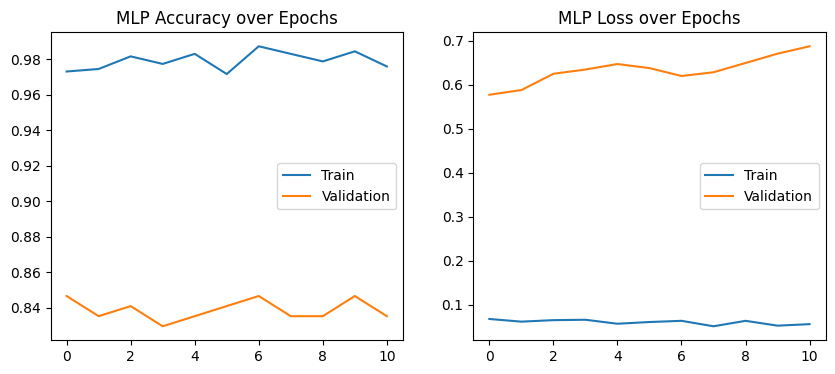

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("MLP Accuracy over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("MLP Loss over Epochs")
plt.legend()
plt.show()

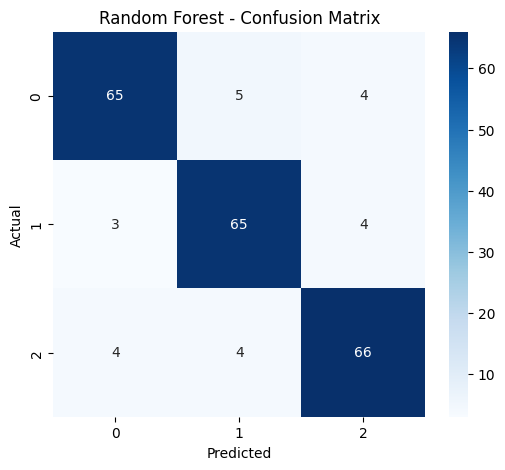

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print("Random Forest CV scores:", rf_cv)
print("Mean CV accuracy:", rf_cv.mean(), "Std:", rf_cv.std())

svm_cv = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print("SVM CV scores:", svm_cv)
print("Mean CV accuracy:", svm_cv.mean(), "Std:", svm_cv.std())

Random Forest CV scores: [0.89772727 0.88636364 0.89204545 0.85795455 0.86363636]
Mean CV accuracy: 0.8795454545454545 Std: 0.0158277139513456
SVM CV scores: [0.89204545 0.89772727 0.89772727 0.83522727 0.84090909]
Mean CV accuracy: 0.8727272727272727 Std: 0.02843180909817455


In [ ]:
#use random forest as main becuse accuracy of 89%

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
